In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# separableConv2D é mais eficiente que Conv2D padrão
from tensorflow.keras.layers import Input, SeparableConv2D, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [3]:
# fashion MNIST roupas em escala de cinza 28x28
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


In [4]:
# canal de cor pra CNN enxergar direito
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape)

(60000, 28, 28, 1)


In [7]:
# classes
K = len(set(y_train))
print('classes:', K)

classes: 10


In [8]:
i = Input(shape=(28, 28, 1))

# bloco 1 — stride 2 reduz pela metade
x = SeparableConv2D(32, (3, 3), strides=2, activation="relu", padding="same")(i)

# bloco 2
x = SeparableConv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)

# bloco 3 — sem stride, só extrai features
x = SeparableConv2D(128, (3, 3), activation="relu", padding="same")(x)

# GlobalAveragePooling em vez de Flatten
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(K, activation="softmax")(x)

model = Model(i, x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 14, 14, 32)     │            73 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 7, 7, 64)       │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 7, 7, 128)      │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,171 (113.95 KB)

 Trainable params: 29,171 (113.95 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.4046 - loss: 1.5273 - val_accuracy: 0.7091 - val_loss: 0.7384
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - accuracy: 0.7109 - loss: 0.7595 - val_accuracy: 0.7633 - val_loss: 0.6283
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7517 - loss: 0.6618 - val_accuracy: 0.7738 - val_loss: 0.6025
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7825 - loss: 0.5948 - val_accuracy: 0.8023 - val_loss: 0.5265
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7945 - loss: 0.5540 - val_accuracy: 0.8084 - val_loss: 0.5055
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8089 - loss: 0.5204 - val_accuracy: 0.8250 - val_loss: 0.4657
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.8218 - loss: 0.4883 - val_accuracy: 0.8358 - val_loss: 0.4446
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8309 -

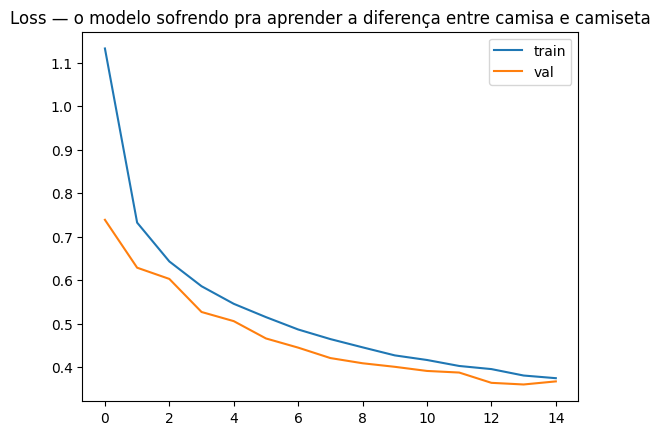

In [11]:
# perda
plt.plot(r.history['loss'], label='train')
plt.plot(r.history['val_loss'], label='val')
plt.title('Loss — o modelo sofrendo pra aprender a diferença entre camisa e camiseta')
plt.legend()
plt.show()

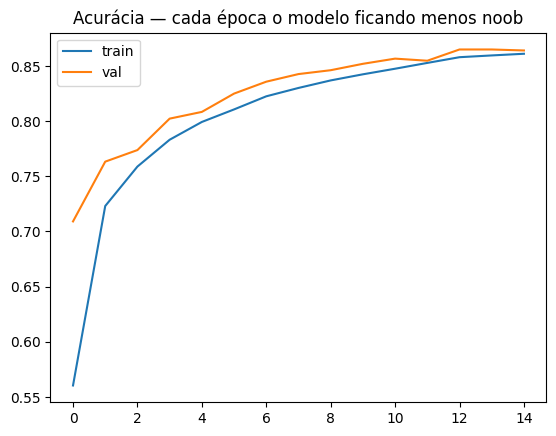

In [12]:
# acurácia
plt.plot(r.history['accuracy'], label='train')
plt.plot(r.history['val_accuracy'], label='val')
plt.title('Acurácia — cada época o modelo ficando menos noob')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix
import itertools

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


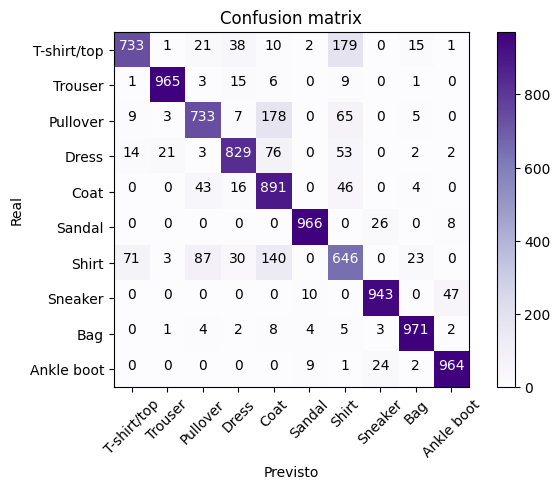

In [14]:
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Purples):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

labels = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
          'Sandal','Shirt','Sneaker','Bag','Ankle boot']

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, labels)

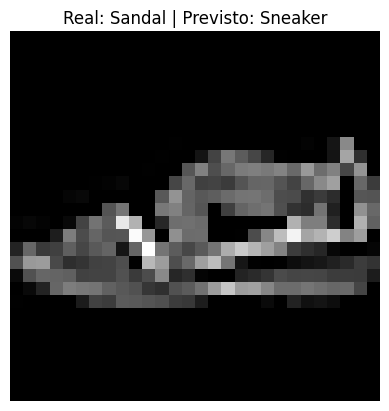

In [17]:
# erro aleatório do modelo
misclassified_idx = np.where(p_test != y_test)[0]
idx = np.random.choice(misclassified_idx)
plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
plt.title(f'Real: {labels[y_test[idx]]} | Previsto: {labels[p_test[idx]]}')
plt.axis('off')
plt.show()